# GANs in PyTorch: from notation to training

We observe

$$
\{X_1,\ldots,X_n\}, \qquad X_i\in\mathbb{R}^d,
$$

and seek a generator

$$
G_\theta:\mathbb{R}^{d'}\to\mathbb{R}^d
$$

such that, for a latent random vector $Z\sim\pi$,

$$
\widetilde X = G_\theta(Z)\overset{d}{\simeq}X.
$$

A discriminator

$$
D_\phi:\mathbb{R}^d\to[0,1]
$$

tries to distinguish observations from the data distribution from observations produced by the generator.

The classical GAN objective is

$$
\min_{\theta}\max_{\phi}
\left[
\mathbb E_{p_X}\{\log D_\phi(X)\}
+
\mathbb E_{p_Z}\{\log(1-D_\phi(G_\theta(Z)))\}
\right].
$$

## Learning objectives

By the end of the practical you should be able to:

1. identify $X$, $Z$, $G_\theta$, $D_\phi$, $d$, and $d'$ in PyTorch code;
2. construct generator and discriminator neural networks;
3. translate the GAN minimax objective into alternating optimisation steps;
4. train a GAN using `torch`;
5. compare the observed and generated distributions.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

PyTorch version: 2.14.0
Device: mps


# 1. Observed data $X_1,\ldots,X_n$

We use a deliberately simple one-dimensional target distribution so that we can inspect the fit visually.

The GAN is **not** given the density below. It sees only the sampled observations.

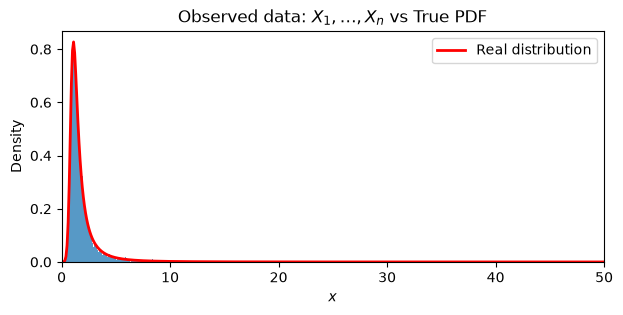

In [2]:
import math 
from torch.distributions import StudentT


n = 100

component = torch.bernoulli(
    torch.full((n, 1), 0.5)
)

X = torch.where(
    component == 0,
    -2.0 + 0.55 * torch.randn(n, 1),
     2.0 + 0.85 * torch.randn(n, 1)
)

gamma = 0.5
rho = -3.0
def burr_quantile(u, gamma=gamma, rho=rho):
    u = np.asarray(u)
    c = -rho / gamma
    d_burr = -1.0 / rho
    return ((1.0 - u) ** (-1.0 / d_burr) - 1.0) ** (1.0 / c)

n = 10_000
U_data = np.random.uniform(size=n)
X_or = burr_quantile(U_data).astype(np.float32).reshape(-1, 1)
X_or= torch.from_numpy(X_or)

plt.figure(figsize=(7, 3))
plt.hist(
    X_or.numpy().ravel(),
    bins=1000,
    density=True,
    alpha=0.75
)
plt.xlim(0, 50)



# --- 1. Real distribution curve in red ---
# Define a dense grid over the x-axis
x_grid = torch.linspace(0, 50.0, 500)

def burr_pdf(y, gamma, rho):
    """
    Calcula la PDF de la variable transformada Y = arcsinh( X),
    donde X sigue la distribución Burr parametrizada por gamma y rho.
    
    Parámetros:
    y (Tensor): Valores transformados donde evaluar la PDF (deben ser > 0).
    gamma (float o Tensor): Parámetro de cola/escala de la Burr original.
    rho (float o Tensor): Parámetro de segundo orden de la Burr original.
    """
    # Protegemos el dominio matemático para y <= 0
    y_safe = torch.where(y > 0, y, torch.tensor(1.0, device=y.device))
    
    # Inversa: Recuperamos el espacio original de X
    x_from_y = y_safe
    
    # Para evitar divisiones por cero o valores negativos en x_from_y si y es muy cercano a 0
    x_safe = torch.where(x_from_y > 0, x_from_y, torch.tensor(1e-7, device=y.device))
    
    # 1. Calculamos la densidad Burr original evaluada en X(y)
    term1 = 1.0 / gamma
    term2 = torch.pow(x_safe, -(1.0 + rho / gamma))
    term3 = torch.pow(1.0 + torch.pow(x_safe, -rho / gamma), (1.0 / rho) - 1.0)
    pdf_x = term1 * term2 * term3
    
    
    
    pdf_y = pdf_x
    
    # Forzar a 0.0 en los valores fuera del dominio transformado (y <= 0)
    return torch.where(y > 0, pdf_y , torch.tensor(0.0, device=y.device))
    
# Calculate the true mixture density
true_density = burr_pdf(x_grid, gamma = gamma, rho = rho) 

# Plot the real distribution in red
plt.plot(
    x_grid.numpy(), 
    true_density.numpy(), 
    color='red', 
    linewidth=2, 
    label="Real distribution"
)

# --- Formatting ---
plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title(r"Observed data: $X_1,\ldots,X_n$ vs True PDF")
plt.legend()
plt.show()


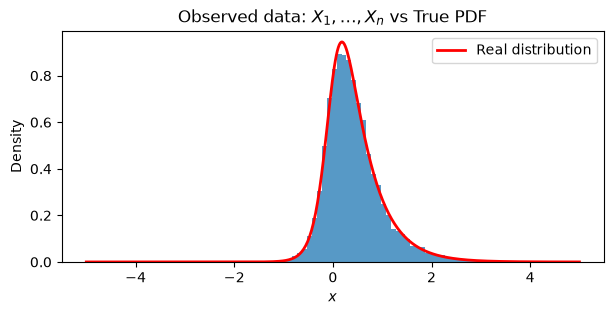

In [3]:
#X = torch.log10(1 + X)
X = torch.log(X_or)
#X = torch.arcsinh(X_or)
#X = torch.from_numpy(X)
#X = (StudentT(df=3.0, loc=0.0, scale=1.0)).sample(sample_shape=(n, d_prime))


plt.figure(figsize=(7, 3))
plt.hist(
    X.numpy().ravel(),
    bins=60,
    density=True,
    alpha=0.75
)




# --- 1. Real distribution curve in red ---
# Define a dense grid over the x-axis
x_grid = torch.linspace(-5.0, 5.0, 500)

def transformed_burr_pdf(y, gamma, rho):
    """
    Calcula la PDF de la variable transformada Y = arcsinh( X),
    donde X sigue la distribución Burr parametrizada por gamma y rho.
    
    Parámetros:
    y (Tensor): Valores transformados donde evaluar la PDF (deben ser > 0).
    gamma (float o Tensor): Parámetro de cola/escala de la Burr original.
    rho (float o Tensor): Parámetro de segundo orden de la Burr original.
    """
    # Protegemos el dominio matemático para y <= 0
    y_safe = y#torch.where(y > 0, y, torch.tensor(1.0, device=y.device))
    
    # Inversa: Recuperamos el espacio original de X
    x_from_y = torch.exp(y_safe)
    #x_from_y = torch.sinh(y_safe)
    
    # Para evitar divisiones por cero o valores negativos en x_from_y si y es muy cercano a 0
    x_safe = torch.where(x_from_y > 0, x_from_y, torch.tensor(1e-7, device=y.device))
    
    # 1. Calculamos la densidad Burr original evaluada en X(y)
    term1 = 1.0 / gamma
    term2 = torch.pow(x_safe, -(1.0 + rho / gamma))
    term3 = torch.pow(1.0 + torch.pow(x_safe, -rho / gamma), (1.0 / rho) - 1.0)
    pdf_x = term1 * term2 * term3
    
    # 2. Multiplicamos por el Jacobiano del cambio de variable: 10^y * ln(10)
    jacobian = torch.exp(y_safe)
    #jacobian = torch.abs(torch.cosh(y_safe))
    
    pdf_y = pdf_x * jacobian
    
    # Forzar a 0.0 en los valores fuera del dominio transformado (y <= 0)
    return pdf_y#torch.where(y > 0, pdf_y , torch.tensor(0.0, device=y.device))
    
# Calculate the true mixture density
true_density = transformed_burr_pdf(x_grid, gamma = gamma, rho = rho) 

# Plot the real distribution in red
plt.plot(
    x_grid.numpy(), 
    true_density.numpy(), 
    color='red', 
    linewidth=2, 
    label="Real distribution"
)

# --- Formatting ---
plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title(r"Observed data: $X_1,\ldots,X_n$ vs True PDF")
plt.legend()
plt.show()

In [4]:
X

tensor([[0.5914],
        [0.0932],
        [0.0253],
        ...,
        [2.1047],
        [0.0178],
        [0.4651]])

# 2. Choose the latent distribution $\pi$

For this example,

$$
d=1,\qquad d'=1,\qquad Z\sim N(0,1).
$$

The latent variable $Z$ provides simple random input. The generator transforms it into a sample that should resemble $X$.

In [5]:
d = 1
d_prime = 1
J = 256

def sample_Z(n):
    return torch.randn(
        n,
        d_prime,
        device=device
    )

#def sample_Z(n):
#    return 2*torch.rand(
#        n,
#        d_prime,
#        device=device
#    ) - 1

Z = sample_Z(100)
print("Z shape:", Z.shape)
#print(Z)

Z shape: torch.Size([100, 1])


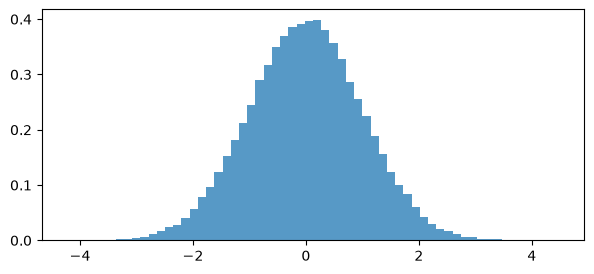

In [6]:
Z_np = sample_Z(100000).cpu().numpy()
plt.figure(figsize=(7, 3))
plt.hist(
    Z_np,
    bins=60,
    density=True,
    alpha=0.75
)
plt.show()

# 3. Construct $G_\theta$ and $D_\phi$

The notation for a one-hidden-layer ReLU generator is

$$
G_\theta^{(m)}(z)
=
\sum_{j=1}^{J}
a_j^{(m)}
\sigma^R\left(
\sum_{i=1}^{d'} w_j^{(i)}z^{(i)}+b_j
\right)
+c^{(m)},
$$

with

$$
\sigma^R(x)=\max(0,x).
$$

In PyTorch:

- `nn.Linear` contains weights and biases;
- `nn.ReLU()` applies $\sigma^R$;
- the final `Linear` layer maps to $\mathbb R^d$.

For the practical we use **two hidden ReLU layers** in both networks. 

The discriminator returns a **logit**
$s_\phi(x)\in\mathbb R$.
When needed,

$$
D_\phi(x)=\operatorname{sigmoid}(s_\phi(x)).
$$

In [7]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_prime, J),
            nn.ReLU(),
            #nn.Linear(J, J),
            #nn.ReLU(),
            nn.Linear(J, d)
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, J),
            nn.ReLU(),
            nn.Linear(J, J),
            nn.ReLU(),
            nn.Linear(J, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


G = Generator().to(device)
D = Discriminator().to(device)

print("Generator G_theta:")
print(G)

print("\nDiscriminator D_phi:")
print(D)

Generator G_theta:
Generator(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=1, bias=True)
  )
)

Discriminator D_phi:
Discriminator(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=1, bias=True)
  )
)


## Check the dimensions

A batch of latent variables has shape

$$
(\text{batch size},d'),
$$

and the generated data have shape

$$
(\text{batch size},d).
$$

In [8]:
with torch.no_grad():
    X_tilde = G(Z)
    prob_real = torch.sigmoid(D(X_tilde))

print("Z shape:", Z.shape)
print("G_theta(Z) shape:", X_tilde.shape)
print("D_phi(G_theta(Z)):", prob_real)

Z shape: torch.Size([100, 1])
G_theta(Z) shape: torch.Size([100, 1])
D_phi(G_theta(Z)): tensor([0.5348, 0.5318, 0.5299, 0.5312, 0.5317, 0.5319, 0.5307, 0.5299, 0.5316,
        0.5317, 0.5319, 0.5354, 0.5317, 0.5351, 0.5318, 0.5307, 0.5333, 0.5317,
        0.5343, 0.5351, 0.5258, 0.5315, 0.5332, 0.5318, 0.5317, 0.5316, 0.5318,
        0.5318, 0.5328, 0.5318, 0.5293, 0.5231, 0.5318, 0.5337, 0.5353, 0.5318,
        0.5343, 0.5317, 0.5318, 0.5344, 0.5234, 0.5319, 0.5317, 0.5330, 0.5323,
        0.5349, 0.5342, 0.5317, 0.5317, 0.5331, 0.5353, 0.5319, 0.5277, 0.5283,
        0.5319, 0.5317, 0.5317, 0.5336, 0.5317, 0.5317, 0.5319, 0.5291, 0.5337,
        0.5309, 0.5318, 0.5317, 0.5341, 0.5353, 0.5317, 0.5319, 0.5293, 0.5342,
        0.5351, 0.5336, 0.5338, 0.5318, 0.5317, 0.5318, 0.5344, 0.5315, 0.5341,
        0.5341, 0.5318, 0.5342, 0.5286, 0.5318, 0.5313, 0.5318, 0.5317, 0.5312,
        0.5321, 0.5326, 0.5327, 0.5294, 0.5318, 0.5321, 0.5317, 0.5355, 0.5319,
        0.5319], device='mps:0')

# 4. From the minimax objective to training

Training alternates between two updates. The classical GAN objective is

$$
\min_{\theta}\max_{\phi}
\left[
\mathbb E_{p_X}\{\log D_\phi(X)\}
+
\mathbb E_{p_Z}\{\log(1-D_\phi(G_\theta(Z)))\}
\right].
$$

### Update the discriminator parameters $\phi$

We want

$$
D_\phi(X)\approx1
$$

for real data and

$$
D_\phi(G_\theta(Z))\approx0
$$

for generated data.

### Update the generator parameters $\theta$

Instead of the saturating minimax generator loss,

$$
\min_{\theta}\mathbb E_{p_Z}\left[\{\log(1-D_\phi(G_\theta(Z)))\}
\right],
$$
we use the standard **non-saturating** loss

$$
\mathcal L_G
=
-\mathbb E_{p_Z}
\left[
\log D_\phi(G_\theta(Z))
\right].
$$

This has the same desired equilibrium but provides stronger gradients early in training.

`BCEWithLogitsLoss` combines the sigmoid and binary cross-entropy calculations in a numerically stable way.

In [9]:
batch_size = min(32,n)

loader = DataLoader(
    TensorDataset(X),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

criterion = nn.BCEWithLogitsLoss()

opt_D = torch.optim.Adam(
    D.parameters(),
    lr=5e-5,
    betas=(0.5, 0.999)
)

opt_G = torch.optim.Adam(
    G.parameters(),
    lr=5e-5,
    betas=(0.5, 0.999)
)

# 5. Train the GAN

The entire adversarial update is kept in one loop.

The key detail is

```python
x_fake = G(z).detach()
```

during the discriminator update: $\phi$ should change, but $\theta$ should not.

In [10]:
epochs = 1000
history_D = []
history_G = []

for epoch in range(epochs):
    d_losses = []
    g_losses = []

    for (x_real,) in loader:
        x_real = x_real.to(device)
        batch_n = x_real.shape[0]

        # --------------------------------
        # 1. Update discriminator phi
        # --------------------------------
        for i in range(2):
            z = sample_Z(batch_n)
            x_fake = G(z).detach()
    
            real_logits = D(x_real)
            fake_logits = D(x_fake)
    
            loss_D = (
                criterion(
                    real_logits,
                    torch.ones_like(real_logits)
                )
                +
                criterion(
                    fake_logits,
                    torch.zeros_like(fake_logits)
                )
            )
    
            opt_D.zero_grad() #clear gradients
            loss_D.backward() #backpropagation
            opt_D.step() #update

        # --------------------------------
        # 2. Update generator theta
        # --------------------------------
        
        z = sample_Z(batch_n)
        x_fake = G(z)
        fake_logits = D(x_fake)

        loss_G = criterion(
            fake_logits,
            torch.ones_like(fake_logits)
        )

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        d_losses.append(loss_D.item())
        g_losses.append(loss_G.item())

    history_D.append(np.mean(d_losses))
    history_G.append(np.mean(g_losses))

    if (epoch + 1) % (epochs/10) == 0:
        print(
            f"Epoch {epoch+1:3d}/{epochs} | "
            f"loss_D = {history_D[-1]:.3f} | "
            f"loss_G = {history_G[-1]:.3f}"
        )

Epoch 100/1000 | loss_D = 1.386 | loss_G = 0.694
Epoch 200/1000 | loss_D = 1.386 | loss_G = 0.695
Epoch 300/1000 | loss_D = 1.386 | loss_G = 0.694
Epoch 400/1000 | loss_D = 1.386 | loss_G = 0.693
Epoch 500/1000 | loss_D = 1.386 | loss_G = 0.693
Epoch 600/1000 | loss_D = 1.386 | loss_G = 0.693
Epoch 700/1000 | loss_D = 1.386 | loss_G = 0.693
Epoch 800/1000 | loss_D = 1.387 | loss_G = 0.693
Epoch 900/1000 | loss_D = 1.386 | loss_G = 0.692
Epoch 1000/1000 | loss_D = 1.386 | loss_G = 0.694


# 6. Diagnostics

GAN losses do not behave like an ordinary regression loss: neither is expected simply to decrease to zero.

A useful evaluation combines the training losses with direct comparison of the real and generated samples.

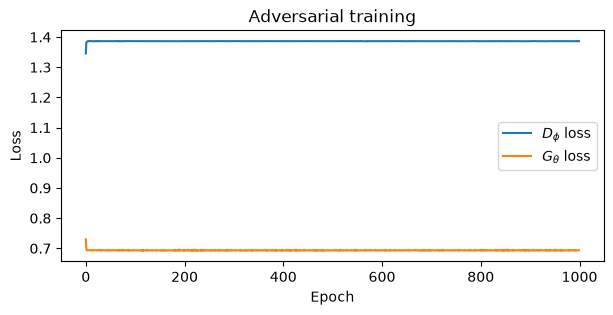

In [11]:
plt.figure(figsize=(7, 3))
plt.plot(history_D, label=r"$D_\phi$ loss")
plt.plot(history_G, label=r"$G_\theta$ loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adversarial training")
plt.legend()
plt.show()

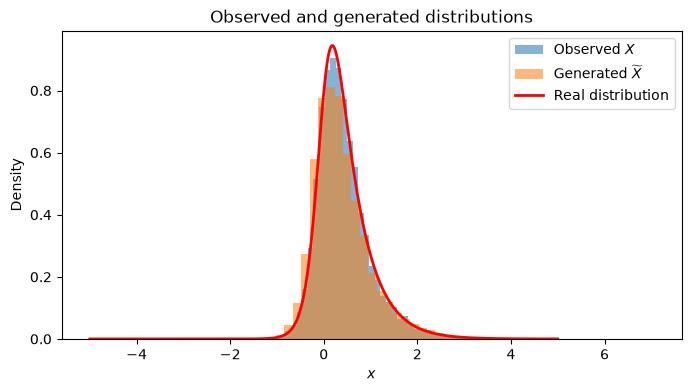

In [12]:
G.eval()

with torch.no_grad():
    X_fake = G(
        sample_Z(1000_000)
    ).cpu().numpy().ravel()

X_real = X.numpy().ravel()

plt.figure(figsize=(8, 4))
plt.hist(
    X_real,
    bins=50,
    density=True,
    alpha=0.55,
    label=r"Observed $X$"
)

plt.hist(
    X_fake,
    bins=50,
    density=True,
    alpha=0.55,
    label=r"Generated $\widetilde X$"
)

# Plot the real distribution in red
plt.plot(
    x_grid.numpy(), 
    true_density.numpy(), 
    color='red', 
    linewidth=2, 
    label="Real distribution"
)

# --- Formatting ---

plt.xlabel(r"$x$")
plt.ylabel("Density")
plt.title(r"Observed and generated distributions")
plt.legend()
plt.show()




## Inspect the learned map $G_\theta$

Because $d=d'=1$, we can plot the generator directly as a function of $z$.

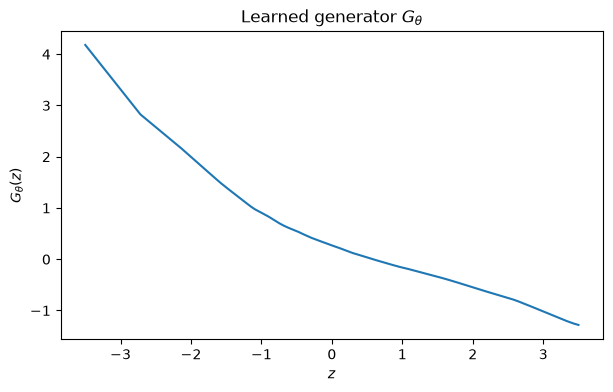

In [13]:
z_grid = torch.linspace(
    -3.5,
    3.5,
    600,
    device=device
).reshape(-1, 1)

with torch.no_grad():
    g_grid = G(z_grid).cpu().numpy().ravel()

plt.figure(figsize=(7, 4))
plt.plot(
    z_grid.cpu().numpy().ravel(),
    g_grid
)
plt.xlabel(r"$z$")
plt.ylabel(r"$G_\theta(z)$")
plt.title(r"Learned generator $G_\theta$")
plt.show()

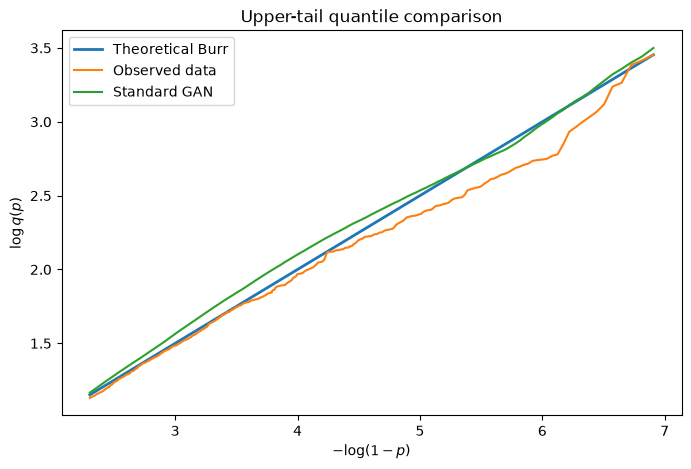

In [18]:
p_tail = np.linspace(0.9, 0.999, 1000)
#X_real_original = X_or
#X_fake_original =np.sinh(X_fake)

X_real_original = X_or
X_fake_original = np.exp(X_fake)

q_theory_tail = burr_quantile(p_tail)
q_data_tail = np.quantile(X_real_original, p_tail)
q_gan_tail = np.quantile(X_fake_original, p_tail)

x_tail = -np.log(1.0 - p_tail)

plt.figure(figsize=(8, 5))

plt.plot(x_tail, np.log(q_theory_tail), label="Theoretical Burr", linewidth=2)
plt.plot(x_tail, np.log(q_data_tail), label="Observed data")
plt.plot(x_tail, np.log(np.maximum(q_gan_tail, 1e-8)), label="Standard GAN")

plt.xlabel(r"$-\log(1-p)$")
plt.ylabel(r"$\log q(p)$")
plt.title("Upper-tail quantile comparison")
plt.legend()

plt.savefig('GAN_Burr.png')
plt.show()

# 7. Discussion and exercises

Try one change at a time.

1. **Latent distribution:** replace $Z\sim N(0,1)$ with $Z\sim U(-1,1)$.
2. **Network width:** change $J$ from 32 to 8 or 128.
3. **Network depth:** remove one hidden layer from $G_\theta$.
4. **Discriminator strength:** give $D_\phi$ two updates for every generator update.
5. **Mode collapse:** repeat training with several random seeds.
6. **Heavy tails:** replace the bimodal data with a Student-$t$ sample and inspect the generated tail.

Questions to discuss:

- What does it mean for the discriminator to become "too good"?
- Why might the generator learn only one mode?
- Why are generated-sample plots often more informative than the raw GAN losses?
- How would you decide whether
  $G_\theta(Z)\overset{d}{\simeq}X$
  is an adequate approximation?